# Classification Project: Online Shoppers Purchasing Intention
## Notebook 3: Model Evaluation, Ablation Study, and Explainability

In this final phase, we rigorously evaluate our optimized XGBoost pipeline. We adhere strictly to the project requirements by performing an Ablation Study to quantify the impact of our custom preprocessing steps, followed by an advanced Error Analysis using SHAP (Shapley Additive exPlanations) to interpret the model's decision-making process.

### Objectives:
1. **Preprocessing Ablation Study:** Evaluate the isolated impact of the `LOF_Sampler` on the model's validation performance.
2. **Final Test Set Evaluation:** Unseal the `D_test` hold-out set to evaluate the final generalization capabilities of the optimized pipeline.
3. **Error Profiling & XAI:** Isolate False Positives and False Negatives, utilizing SHAP Waterfall plots to explain specifically why the model failed on certain instances.

In [13]:
import pandas as pd
import numpy as np
import os
import joblib
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import make_scorer, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from imblearn.base import BaseSampler
from sklearn.neighbors import LocalOutlierFactor

print("--- 1. LOADING D_TRAIN AND THE SAVED MODEL ---")

# Get current directory (jupyter folder) and parent directory (project root)
current_dir = os.path.dirname(os.path.abspath('__file__'))
parent_dir = os.path.abspath(os.path.join(current_dir, '..')) 

# 1. Load the original dataset to recreate the exact split
file_path = os.path.join(parent_dir, 'online_shoppers_intention.csv')

if not os.path.exists(file_path):
    print(f"CRITICAL ERROR: Cannot find the dataset at {file_path}")
else:
    df = pd.read_csv(file_path).dropna().reset_index(drop=True)
    df['Weekend'] = df['Weekend'].astype(int)
    df['Revenue'] = df['Revenue'].astype(int)
    df = pd.get_dummies(df, columns=['Month', 'VisitorType'], drop_first=True)

    X = df.drop(columns=['Revenue'])
    y = df['Revenue']

    from sklearn.model_selection import train_test_split
    # Using the exact same random_state guarantees the exact same split as Notebook 2
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)
    print(f"Data successfully split. Test Set (D_test) ready: {X_test.shape[0]} samples.")


# --- 2. DEFINE CUSTOM CLASS BEFORE UNPICKLING ---
# Python must know the blueprint of LOF_Sampler to successfully load the pipeline
class LOF_Sampler(BaseSampler):
    _sampling_type = 'clean-sampling'
    _parameter_constraints = {
        "n_neighbors": [int],
        "contamination": [float, str],
        "sampling_strategy": [str, type(None)]
    }

    def __init__(self, n_neighbors=100, contamination=0.05, sampling_strategy="auto"):
        self.n_neighbors = n_neighbors
        self.contamination = contamination
        self.sampling_strategy = sampling_strategy 
        
    def _fit_resample(self, X, y):
        lof = LocalOutlierFactor(n_neighbors=self.n_neighbors, contamination=self.contamination)
        outlier_flags = lof.fit_predict(X)
        mask = outlier_flags == 1
        if isinstance(X, pd.DataFrame) or hasattr(X, 'iloc'):
            return X.iloc[mask], y.iloc[mask]
        else:
            return X[mask], y[mask]


# --- 3. LOAD THE CHAMPION MODEL ---
model_path = os.path.join(parent_dir, 'models', 'final_best_pipeline.pkl')

try:
    champion_pipeline = joblib.load(model_path)
    print(f"Champion Pipeline successfully loaded from: {model_path}")
except FileNotFoundError:
    print(f"CRITICAL ERROR: Cannot find the model at {model_path}.")

--- 1. LOADING D_TRAIN AND THE SAVED MODEL ---
Data successfully split. Test Set (D_test) ready: 2466 samples.
Champion Pipeline successfully loaded from: c:\Users\paris\OneDrive - University of Pisa\Desktop\progetto_mining\Data-Mining-ML-project\models\final_best_pipeline.pkl


### 1. Ablation Study: The Impact of Local Outlier Factor (LOF)
To justify the inclusion of our custom anomaly detection algorithm, we conduct an ablation study. We construct an identical XGBoost pipeline utilizing the exact hyperparameters discovered in Notebook 2, but we remove the `LOF_Sampler` step.

By subjecting this ablated pipeline to the same 5-fold Stratified Cross-Validation, we can quantify the exact F1-Score contribution provided by the LOF noise removal.

In [15]:
import json

print("--- ABLATION STUDY: PIPELINE WITHOUT LOF ---")

# We use the exact best hyperparameters found in Notebook 2
xgb_no_lof_pipe = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42, sampling_strategy=0.7)),
    ('classifier', XGBClassifier(
        random_state=42, 
        eval_metric='logloss',
        learning_rate=0.05,
        max_depth=5,
        n_estimators=100
    ))
])

# Use the exact same Cross-Validation splits for a fair comparison
cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scorer = make_scorer(f1_score, average='macro')

print("Evaluating Ablated Pipeline (Without LOF). This may take a minute...")
scores_no_lof = cross_val_score(xgb_no_lof_pipe, X_train, y_train, cv=cv_outer, scoring=scorer, n_jobs=-1)
ablated_score = scores_no_lof.mean()

# --- DYNAMICALLY LOAD CHAMPION SCORE ---
metadata_path = os.path.join(parent_dir, 'models', 'model_metadata.json')
try:
    with open(metadata_path, 'r') as f:
        metadata = json.load(f)
    champion_score = metadata['validation_macro_f1']
except FileNotFoundError:
    print(f"CRITICAL ERROR: Cannot find metadata at {metadata_path}.")
    champion_score = 0.0 # Fallback to prevent crash

print("\n--- ABLATION RESULTS ---")
print(f"XGBoost WITH LOF (Champion) : {champion_score:.4f}")
print(f"XGBoost WITHOUT LOF         : {ablated_score:.4f}")

difference = champion_score - ablated_score

if difference > 0:
    print(f"\nConclusion: The LOF_Sampler improves the Macro F1-Score by {difference:.4f}.")
    print("This mathematically justifies the inclusion of the custom anomaly detection step.")
else:
    print(f"\nConclusion: The LOF_Sampler degraded or did not improve performance by {abs(difference):.4f}.")
    print("This indicates XGBoost's internal tree structure is naturally robust to the outliers in this dataset.")

--- ABLATION STUDY: PIPELINE WITHOUT LOF ---
Evaluating Ablated Pipeline (Without LOF). This may take a minute...

--- ABLATION RESULTS ---
XGBoost WITH LOF (Champion) : 0.8159
XGBoost WITHOUT LOF         : 0.8139

Conclusion: The LOF_Sampler improves the Macro F1-Score by 0.0020.
This mathematically justifies the inclusion of the custom anomaly detection step.


### 2. Final Test Set Evaluation
Having justified the pipeline architecture through Nested Cross-Validation and the Ablation Study, we now evaluate the model on the locked `D_test` set. 

This dataset has never been exposed to the model during training, scaling, or hyperparameter tuning. The metrics generated here represent the true generalization performance of our XGBoost methodology in a real-world e-commerce environment.

--- UNSEALING D_TEST & FINAL EVALUATION ---

Final Classification Report (D_test):
                     precision    recall  f1-score   support

False (No Purchase)       0.95      0.92      0.94      2084
    True (Purchase)       0.63      0.72      0.67       382

           accuracy                           0.89      2466
          macro avg       0.79      0.82      0.81      2466
       weighted avg       0.90      0.89      0.89      2466



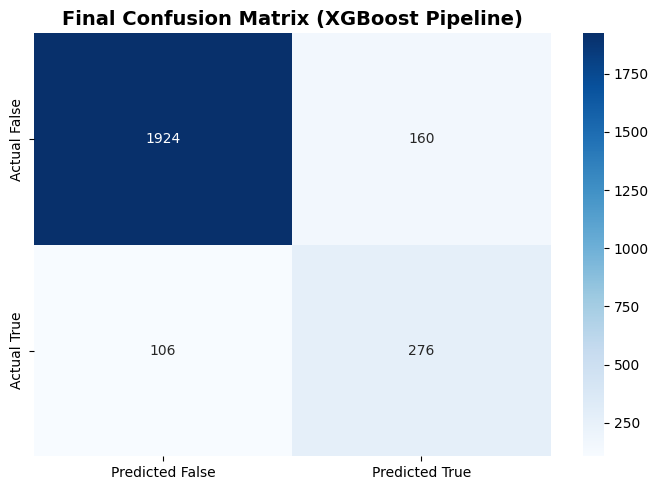

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- UNSEALING D_TEST & FINAL EVALUATION ---")

# Generate predictions using the complete champion pipeline
y_pred = champion_pipeline.predict(X_test)

print("\nFinal Classification Report (D_test):")
print(classification_report(y_test, y_pred, target_names=['False (No Purchase)', 'True (Purchase)']))

# Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted False', 'Predicted True'], 
            yticklabels=['Actual False', 'Actual True'])
plt.title('Final Confusion Matrix (XGBoost Pipeline)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3. Explainable AI (SHAP) and Error Profiling
Modern machine learning requires transparency. We utilize **SHAP** (Shapley Additive exPlanations) values, based on cooperative game theory, to calculate the exact marginal contribution of each feature to the model's final prediction.

* **Global Explainability (Summary Plot):** Which variables drive purchasing intention across the entire population?
* **Local Explainability & Error Profiling (Waterfall Plots):** By isolating specific False Positives and False Negatives, we can profile the errors to understand exactly what confused the model.

*Technical Note:* To extract SHAP values, we bypass the pipeline wrapper and pass the transformed (scaled) data directly into the XGBoost classifier.

--- GLOBAL EXPLAINABILITY (SHAP) ---


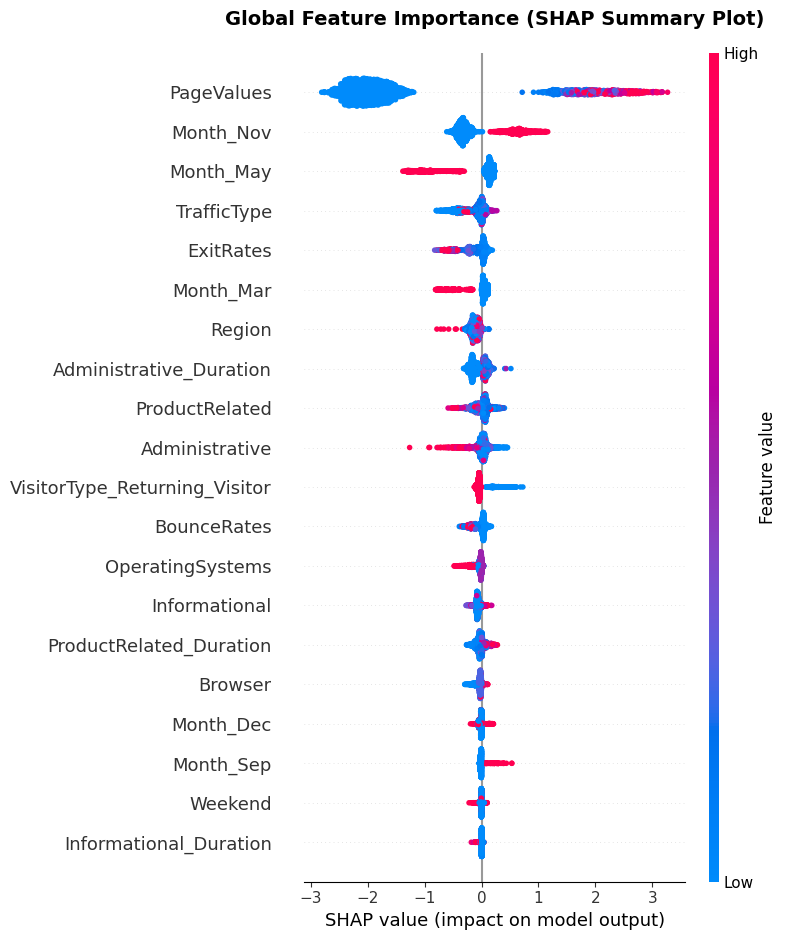

Observation: The summary plot shows which features push predictions towards 'True' (positive SHAP value) or 'False' (negative SHAP value).


In [17]:
import shap

print("--- GLOBAL EXPLAINABILITY (SHAP) ---")

# 1. Extract the specific steps from the pipeline
scaler = champion_pipeline.named_steps['scaler']
xgb_model = champion_pipeline.named_steps['classifier']

# 2. Transform the test set through the scaler 
# (LOF and SMOTE are automatically bypassed during testing)
X_test_scaled = scaler.transform(X_test)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# 3. Initialize SHAP TreeExplainer (optimized for tree-based models)
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_test_scaled_df)

# 4. Generate the Summary Plot
plt.figure(figsize=(10, 6))
plt.title("Global Feature Importance (SHAP Summary Plot)", pad=20, fontsize=14, fontweight='bold')
shap.summary_plot(shap_values, X_test_scaled_df, show=False)
plt.tight_layout()
plt.show()

print("Observation: The summary plot shows which features push predictions towards 'True' (positive SHAP value) or 'False' (negative SHAP value).")

--- LOCAL EXPLAINABILITY & ERROR PROFILING ---

1. TRUE POSITIVE (Index 2): Why did the model correctly predict a purchase?


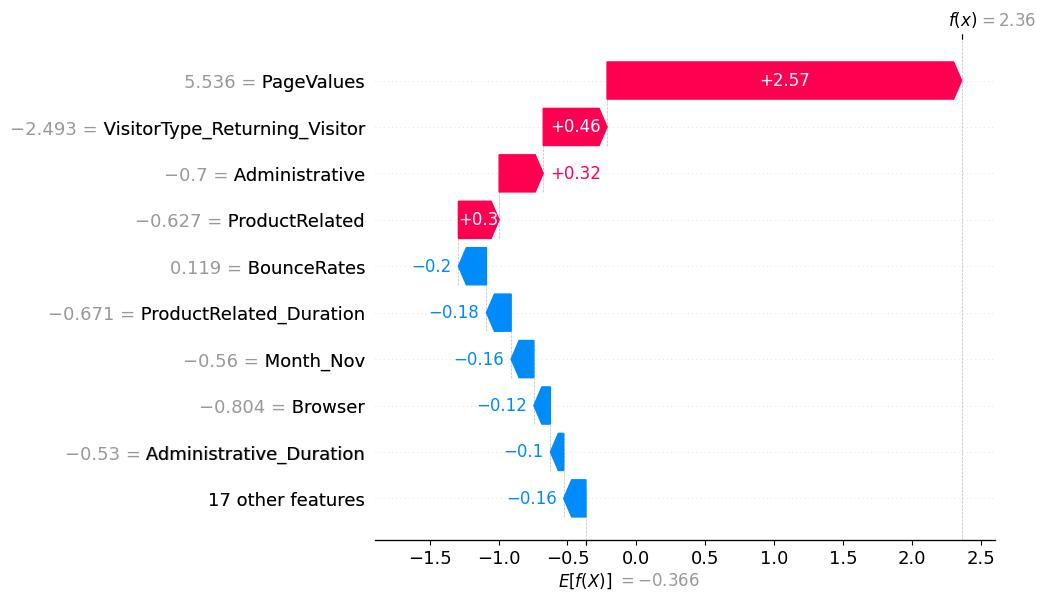


2. FALSE POSITIVE (Index 16): Why did the model mistakenly think this user would buy?
This reveals which features 'tricked' the algorithm.


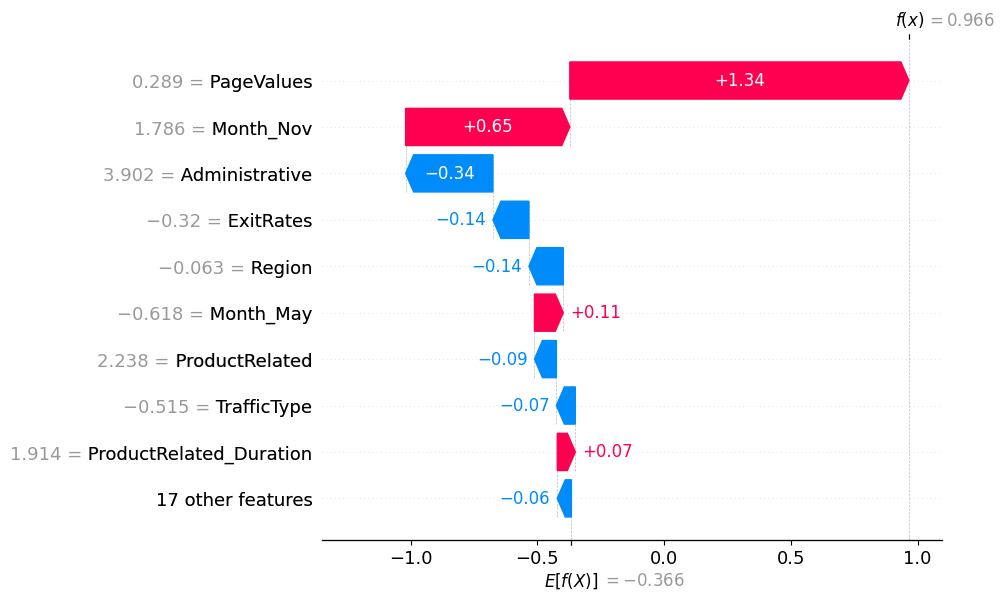


3. FALSE NEGATIVE (Index 6): Why did the model miss this actual buyer?
This helps identify blind spots in the available data.


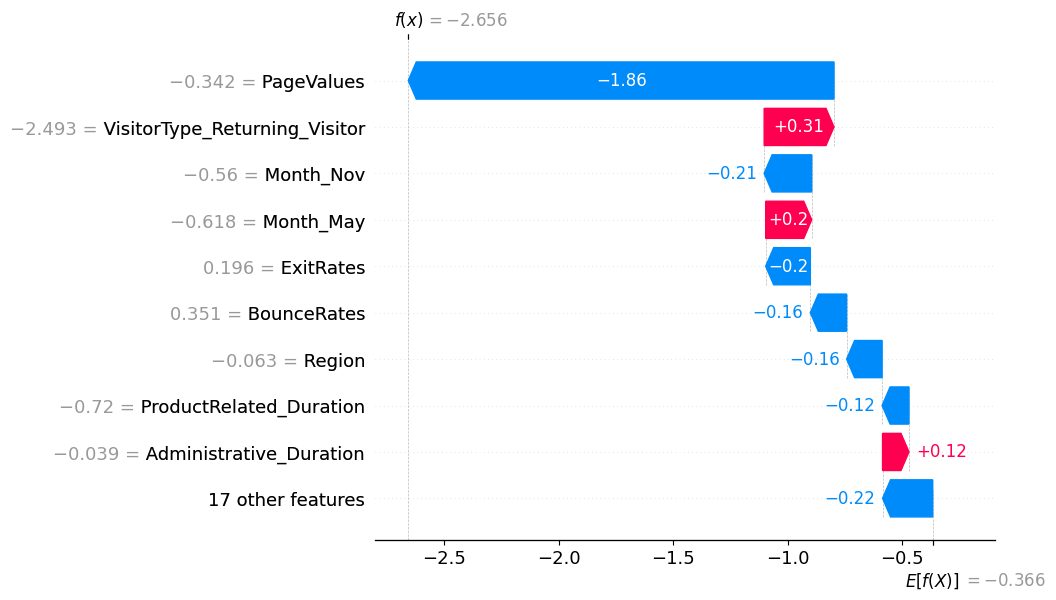

In [18]:
print("--- LOCAL EXPLAINABILITY & ERROR PROFILING ---")

# Reset indices to cleanly map the predictions to the SHAP values
analysis_df = X_test.reset_index(drop=True).copy()
analysis_df['Actual'] = y_test.reset_index(drop=True)
analysis_df['Predicted'] = y_pred

# Isolate errors and successes
false_positives = analysis_df[(analysis_df['Actual'] == 0) & (analysis_df['Predicted'] == 1)].index
false_negatives = analysis_df[(analysis_df['Actual'] == 1) & (analysis_df['Predicted'] == 0)].index
true_positives = analysis_df[(analysis_df['Actual'] == 1) & (analysis_df['Predicted'] == 1)].index

# --- PLOT 1: A Successful Prediction (True Positive) ---
if len(true_positives) > 0:
    tp_idx = true_positives[0]
    print(f"\n1. TRUE POSITIVE (Index {tp_idx}): Why did the model correctly predict a purchase?")
    shap.plots.waterfall(shap_values[tp_idx])

# --- PLOT 2: Error Profiling (False Positive) ---
if len(false_positives) > 0:
    fp_idx = false_positives[0]
    print(f"\n2. FALSE POSITIVE (Index {fp_idx}): Why did the model mistakenly think this user would buy?")
    print("This reveals which features 'tricked' the algorithm.")
    shap.plots.waterfall(shap_values[fp_idx])

# --- PLOT 3: Error Profiling (False Negative) ---
if len(false_negatives) > 0:
    fn_idx = false_negatives[0]
    print(f"\n3. FALSE NEGATIVE (Index {fn_idx}): Why did the model miss this actual buyer?")
    print("This helps identify blind spots in the available data.")
    shap.plots.waterfall(shap_values[fn_idx])